# Feature Space Analysis

Investigates the geometric feature extractors along two axes:

- **Part A — Invariance**: are feature vectors unchanged after a rigid transformation?
  Measured as the MAE between original and transformed feature vectors, reported as a
  distribution per cloud style (boxplots). Verified visually via PCA overlays.
- **Part B — Redundancy**: Spearman correlation matrix with named feature axes;
  PCA scree plot showing how many independent dimensions the features carry.

In [17]:
import sys
sys.path.insert(0, '../src')

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import spearmanr
from sklearn.decomposition import PCA

from point_cloud import PointCloud
from synthetic import SyntheticExperiment, CloudStyle
from feature_extractor import (
    GeometricFeatureExtractor,
    RobustGeometricFeatureExtractor,
    zscored_features,
)
from transformation import RigidTransformation

STYLES: list[CloudStyle] = ['random', 'clustered', 'lattice', '2d-lattice', 'muscle-fiber']
STYLE_COLORS = {
    'random':       'tab:blue',
    'clustered':    'tab:orange',
    'lattice':      'tab:green',
    '2d-lattice':   'tab:red',
    'muscle-fiber': 'tab:purple',
}

EXTRACTORS = {
    'Geometric (9-dim)': GeometricFeatureExtractor(k=20),
    'Robust (11-dim)':   RobustGeometricFeatureExtractor(k=20),
}

# Human-readable names matching the order features are stacked in each extractor.
FEATURE_NAMES = {
    'Geometric (9-dim)': [
        'd_min/d̄', 'std/d̄', 'centroid_offset',
        'linearity', 'planarity', 'sphericity', 'anisotropy',
        'angle_mean', 'angle_std',
    ],
    'Robust (11-dim)': [
        'dist_Q25', 'dist_Q50', 'dist_Q75', 'centroid_offset',
        'linearity', 'planarity', 'sphericity', 'anisotropy',
        'angle_Q25', 'angle_Q50', 'angle_Q75',
    ],
}

N_POINTS  = 2000
N_SEEDS   = 5    # different source clouds per style
N_TRANSFORMS = 5 # random rigid transforms per (style, seed)
BASE_SEED = 42

## Part A — Invariance under rigid transformations

For each `(cloud style, seed)` pair we generate a source cloud, extract features,
then apply `N_TRANSFORMS` random rigid transforms and re-extract features on the
transformed cloud. The Mean Absolute Error (MAE) averaged over all points and all
feature dimensions gives one scalar per trial. Collecting these over seeds and
transforms yields a distribution of errors per cloud style.

A truly invariant extractor should produce MAE at floating-point precision (≈ 1e-14).

In [18]:
# mae_data[ext_name][style] -> 1-D array of MAE values (len = N_SEEDS * N_TRANSFORMS)
mae_data: dict[str, dict[str, np.ndarray]] = {name: {} for name in EXTRACTORS}

for style in STYLES:
    for ext_name, extractor in EXTRACTORS.items():
        errors = []
        for seed in range(N_SEEDS):
            cloud = SyntheticExperiment.generate(
                n=N_POINTS, style=style, seed=BASE_SEED + seed
            ).S
            feat_orig = extractor.get_features(cloud)       # (N, D)
            for t in range(N_TRANSFORMS):
                rng = np.random.default_rng(BASE_SEED + seed * 100 + t)
                T = RigidTransformation.random(noise_std=0.0, t_scale=10.0)
                feat_transformed = extractor.get_features(T.apply(cloud))  # (N, D)
                mae = np.abs(feat_orig - feat_transformed).mean()
                errors.append(mae)
        mae_data[ext_name][style] = np.array(errors)

print('MAE computation done.')

MAE computation done.


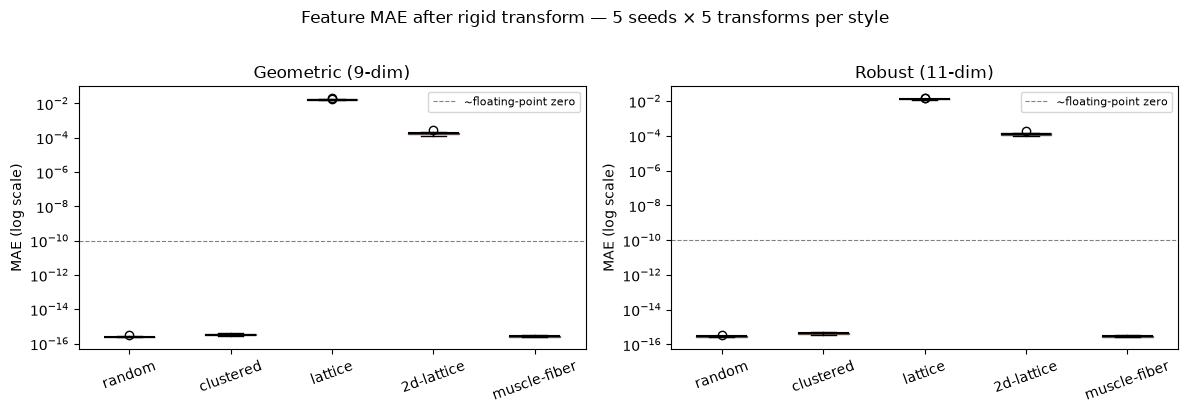

In [19]:
fig, axes = plt.subplots(1, len(EXTRACTORS), figsize=(6 * len(EXTRACTORS), 4), sharey=False)

for ax, ext_name in zip(axes, EXTRACTORS):
    data_per_style = [mae_data[ext_name][s] for s in STYLES]
    bp = ax.boxplot(
        data_per_style,
        tick_labels=STYLES,
        patch_artist=True,
        medianprops=dict(color='black', linewidth=1.5),
    )
    for patch, style in zip(bp['boxes'], STYLES):
        patch.set_facecolor(STYLE_COLORS[style])
        patch.set_alpha(0.6)
    ax.set_yscale('log')
    ax.set_ylabel('MAE (log scale)')
    ax.set_title(ext_name)
    ax.tick_params(axis='x', rotation=20)
    ax.axhline(1e-10, color='grey', linestyle='--', linewidth=0.8, label='~floating-point zero')
    ax.legend(fontsize=8)

fig.suptitle(
    f'Feature MAE after rigid transform — {N_SEEDS} seeds × {N_TRANSFORMS} transforms per style',
    y=1.02,
)
plt.tight_layout()
plt.savefig('../results/14_feature_invariance_mae.png', dpi=200, bbox_inches='tight')
plt.show()

### A.2 — PCA overlay: original vs transformed feature space

For one seed per cloud style, we fit PCA on the original feature matrix and project
both the original and one transformed cloud into the same 2D space. If features are
invariant the two point clouds overlap exactly.

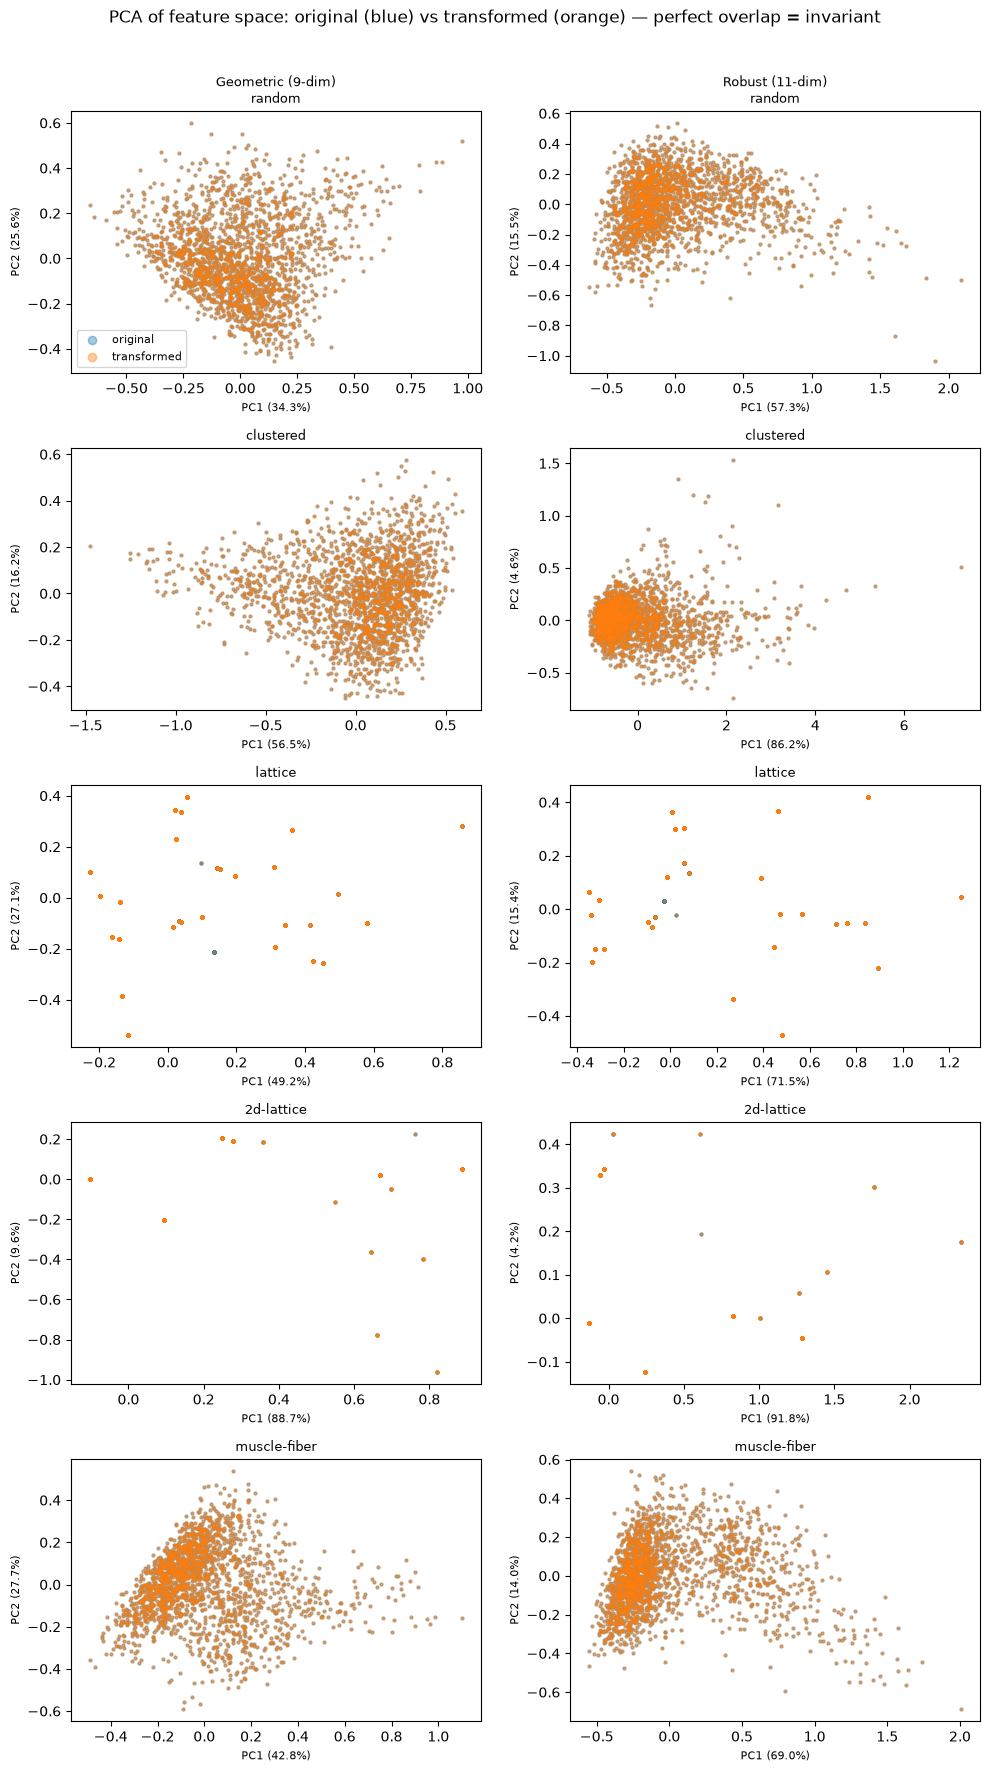

In [20]:
N_COLS = len(EXTRACTORS)
N_ROWS = len(STYLES)
fig, axes = plt.subplots(
    N_ROWS, N_COLS,
    figsize=(5 * N_COLS, 3.5 * N_ROWS),
    squeeze=False,
)

# Fixed transform for visual consistency across styles
T_fixed = RigidTransformation.random(noise_std=0.0, t_scale=10.0)

for row, style in enumerate(STYLES):
    cloud = SyntheticExperiment.generate(n=N_POINTS, style=style, seed=BASE_SEED).S
    cloud_transformed = T_fixed.apply(cloud)

    for col, (ext_name, extractor) in enumerate(EXTRACTORS.items()):
        ax = axes[row, col]
        feat_orig = extractor.get_features(cloud)              # (N, D)
        feat_trans = extractor.get_features(cloud_transformed) # (N, D)

        pca2 = PCA(n_components=2).fit(feat_orig)
        proj_orig  = pca2.transform(feat_orig)   # (N, 2)
        proj_trans = pca2.transform(feat_trans)  # (N, 2)

        ax.scatter(proj_orig[:, 0],  proj_orig[:, 1],
                   s=4, alpha=0.4, color='tab:blue',   label='original')
        ax.scatter(proj_trans[:, 0], proj_trans[:, 1],
                   s=4, alpha=0.4, color='tab:orange', label='transformed')

        var = pca2.explained_variance_ratio_
        ax.set_xlabel(f'PC1 ({var[0]:.1%})', fontsize=8)
        ax.set_ylabel(f'PC2 ({var[1]:.1%})', fontsize=8)
        title = f'{style}' if row == 0 else style
        ax.set_title(f'{ext_name}\n{style}' if row == 0 else style, fontsize=9)
        if row == 0 and col == 0:
            ax.legend(fontsize=8, markerscale=3)

fig.suptitle(
    'PCA of feature space: original (blue) vs transformed (orange) — perfect overlap = invariant',
    y=1.01,
)
plt.tight_layout()
plt.savefig('../results/14_feature_invariance_pca.png', dpi=200, bbox_inches='tight')
plt.show()

## Part B — Feature redundancy

Two views:

1. **Spearman correlation matrix** — pairwise rank correlation between named feature dimensions.
2. **PCA scree plot** — how many principal components are needed to explain 90% of variance?

In [21]:
# Pool z-scored features across all cloud styles for each extractor
all_features: dict[str, np.ndarray] = {}
all_style_labels: dict[str, list[str]] = {}

for ext_name, extractor in EXTRACTORS.items():
    clouds = [
        SyntheticExperiment.generate(n=N_POINTS, style=s, seed=BASE_SEED).S
        for s in STYLES
    ]
    feats_list = zscored_features(extractor, clouds)       # list of (N, D)
    all_features[ext_name] = np.concatenate(feats_list, axis=0)  # (N*5, D)
    all_style_labels[ext_name] = [
        s for s, f in zip(STYLES, feats_list) for _ in range(len(f))
    ]

print({k: v.shape for k, v in all_features.items()})

{'Geometric (9-dim)': (10008, 9), 'Robust (11-dim)': (10008, 11)}


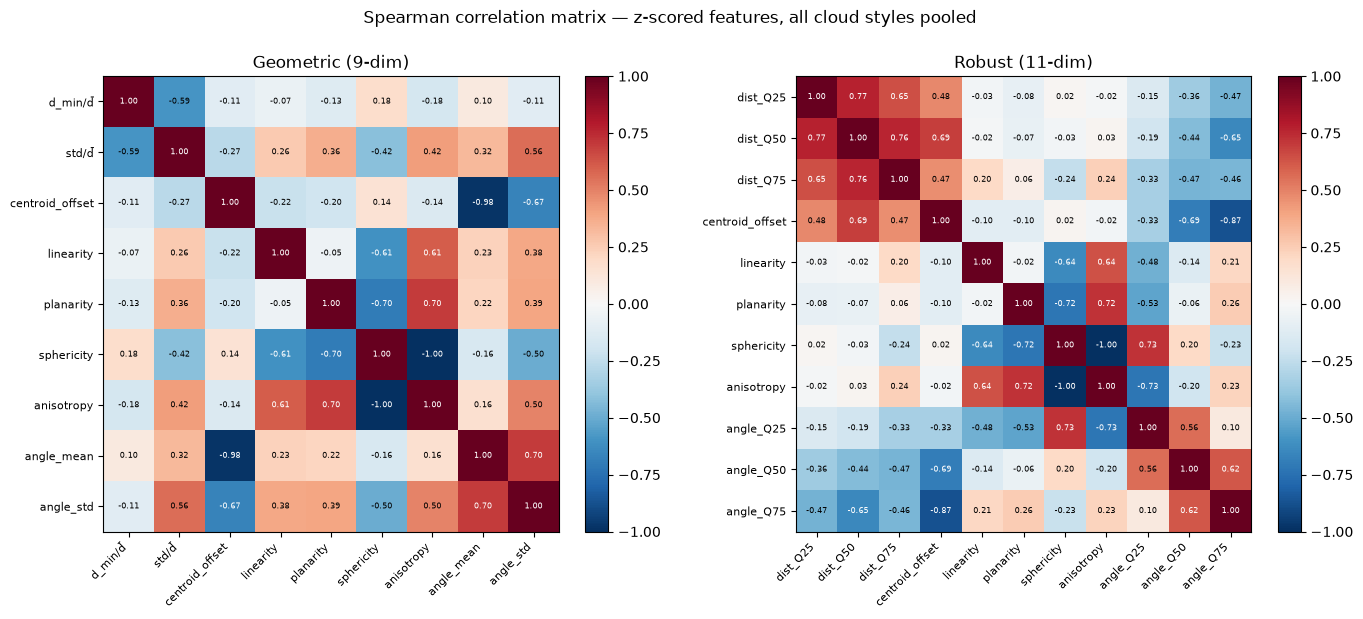

In [22]:
fig, axes = plt.subplots(1, len(EXTRACTORS), figsize=(7 * len(EXTRACTORS), 6))

for ax, (ext_name, feats) in zip(axes, all_features.items()):
    feat_names = FEATURE_NAMES[ext_name]
    corr_result = spearmanr(feats)
    # spearmanr returns a scalar when D=2, otherwise a correlation matrix
    corr = np.atleast_2d(corr_result.statistic)

    im = ax.imshow(corr, vmin=-1, vmax=1, cmap='RdBu_r')
    D = len(feat_names)
    ax.set_xticks(range(D))
    ax.set_yticks(range(D))
    ax.set_xticklabels(feat_names, rotation=45, ha='right', fontsize=8)
    ax.set_yticklabels(feat_names, fontsize=8)
    for i in range(D):
        for j in range(D):
            ax.text(j, i, f'{corr[i, j]:.2f}',
                    ha='center', va='center', fontsize=6,
                    color='white' if abs(corr[i, j]) > 0.6 else 'black')
    plt.colorbar(im, ax=ax, fraction=0.046)
    ax.set_title(ext_name)

fig.suptitle('Spearman correlation matrix — z-scored features, all cloud styles pooled', y=1.01)
plt.tight_layout()
plt.savefig('../results/14_feature_correlation.png', dpi=200, bbox_inches='tight')
plt.show()

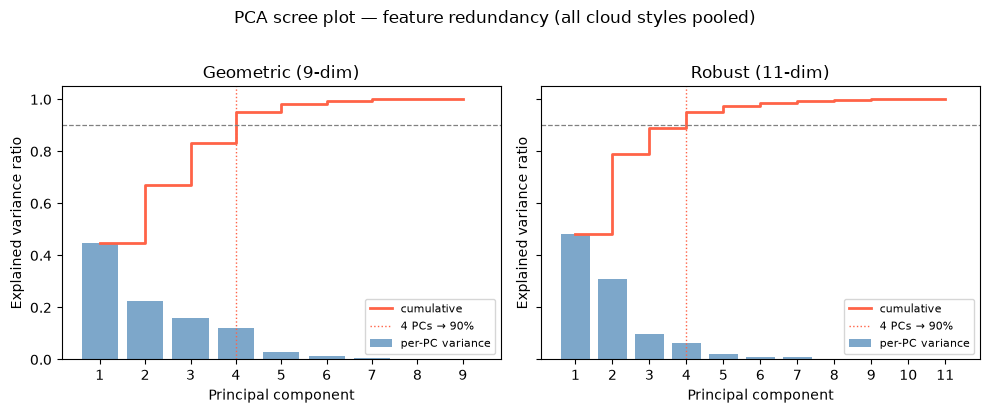

In [23]:
fig, axes = plt.subplots(1, len(EXTRACTORS), figsize=(5 * len(EXTRACTORS), 4), sharey=True)

for ax, (ext_name, feats) in zip(axes, all_features.items()):
    pca = PCA().fit(feats)
    cumvar = np.cumsum(pca.explained_variance_ratio_)
    n90 = int(np.searchsorted(cumvar, 0.90)) + 1

    ax.bar(
        range(1, len(cumvar) + 1),
        pca.explained_variance_ratio_,
        color='steelblue', alpha=0.7, label='per-PC variance',
    )
    ax.step(
        range(1, len(cumvar) + 1), cumvar,
        where='post', color='tomato', linewidth=2, label='cumulative',
    )
    ax.axhline(0.90, color='grey', linestyle='--', linewidth=0.9)
    ax.axvline(n90, color='tomato', linestyle=':', linewidth=1,
               label=f'{n90} PCs → 90%')
    ax.set_xticks(range(1, len(cumvar) + 1))
    ax.set_xlabel('Principal component')
    ax.set_ylabel('Explained variance ratio')
    ax.set_title(ext_name)
    ax.legend(fontsize=8)

fig.suptitle('PCA scree plot — feature redundancy (all cloud styles pooled)', y=1.02)
plt.tight_layout()
plt.savefig('../results/14_feature_pca_scree.png', dpi=200, bbox_inches='tight')
plt.show()